# Readme
This is a demo notebook that shows how a personal schema is loaded and how to add data to it.
It's also great to test how to add new tables and how this affects your pipeline.

Once you are done with the tutorial, drop your schema by calling: `schema.drop()`.
This is also described at the very end of the tutorial.

If you have not installed `djimaging`, please go to project directory and install it via `pip install -e .`, see also below.

In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import datajoint as dj

# Setup

In [20]:
username = !whoami
username = username[0]
username

'ssuhai'

In [4]:
home_directory = os.path.expanduser("~")
home_directory

'/gpfs01/euler/User/ssuhai'

In [7]:
# Path to djimaging
path_to_djimaging = f'{home_directory}/GitRepos/'

# Clone djimaging if you haven't downloaded it yet
# assert os.isdir(path_to_djimaging), 'Create target folder before cloning djimaging'
# !cd {path_to_djimaging} && git clone git@github.com:eulerlab/djimaging.git

# Install djimaging if not done yet
# assert os.isdir(os.path.join(path_to_djimaging, 'djimaging')), 'Create target folder before cloning djimaging'
# !cd {path_to_djimaging}/djimaging/ && sudo pip install -e .

# Data Base

## Prepare dj config

In [8]:
# Set config file
config_file = f'{home_directory}/datajoint/dj_{username}_conf.json'
assert os.path.isfile(config_file), f'Set the path to your config file: {config_file}'

In [9]:
# Define a schema name or use the default name for your personal test schema
# It should start with ageuler and have some meaningful name after that
schema_name = f"ageuler_{username}_test"

In [10]:
# Do you want to use the RGC classifier?
# If so, make sure to add the respective tables into your schema.
use_rgc_classifier = False

if use_rgc_classifier:  # Define any existing outputfolder for the classifier to be saved
    output_folder = f'{home_directory}/datajoint/rgc_classifier'
    assert os.path.isdir(output_folder), f'Set path to output directory: {output_folder}'

In [11]:
# Load configuration for user
dj.config.load(config_file)
dj.config['schema_name'] = schema_name

if use_rgc_classifier:
    from djimaging.tables.classifier.rgc_classifier import prepare_dj_config_rgc_classifier
    prepare_dj_config_rgc_classifier(output_folder)

print("schema_name:", dj.config['schema_name'])
dj.conn()

[2025-04-17 18:52:11,225][INFO]: Connecting ssuhai@172.25.240.200:3306
[2025-04-17 18:52:11,287][INFO]: Connected ssuhai@172.25.240.200:3306


schema_name: ageuler_ssuhai_test


DataJoint connection (connected) ssuhai@172.25.240.200:3306

## Create or load schema

In [12]:
# Import your own schema, which defines the tables you will have in your database and how they are connected.
from djimaging.user.ssuhai.schemas.ssuhai_schema import *

In [11]:
if use_rgc_classifier:
    try:
        CelltypeAssignment()
    except Exception as e:
        import warnings
        warnings.warn("""
            If you want to include the RGC classifier in your database, you have to copy the respective tables from 
            djimaging/schemas/full_rgc_schema.py 
            to the schema you just imported (see above).
            Then restart the notebook and try again.
            """)

## Important note

If the schema with the name `schema_name = f"ageuler_{username}_test"` already exists, it is important that the schema definition here is the same as it was when the schema was created.
If you did the other tutorial first, and did not delete (=drop) the schema afterwards, this will not be the case, for example.
Then you already have a schema with the same name but different tables, the first being based on the schema `rgc_classifier_schema`, and this one being based on `my_schema`. This can result in a variety of problems, so you either have to change the schema name here or drop the old schema first.

Outside of this tutorial, in most cases, you want exactly one schema per project to never run into this problem.

In [13]:
from djimaging.utils.dj_utils import activate_schema

activate_schema(schema=schema, create_schema=True, create_tables=True)
schema

Schema `ageuler_ssuhai_test`

# ERD

[2025-04-21 19:53:40,434][WARNING]: MySQL server has gone away. Reconnecting to the server.


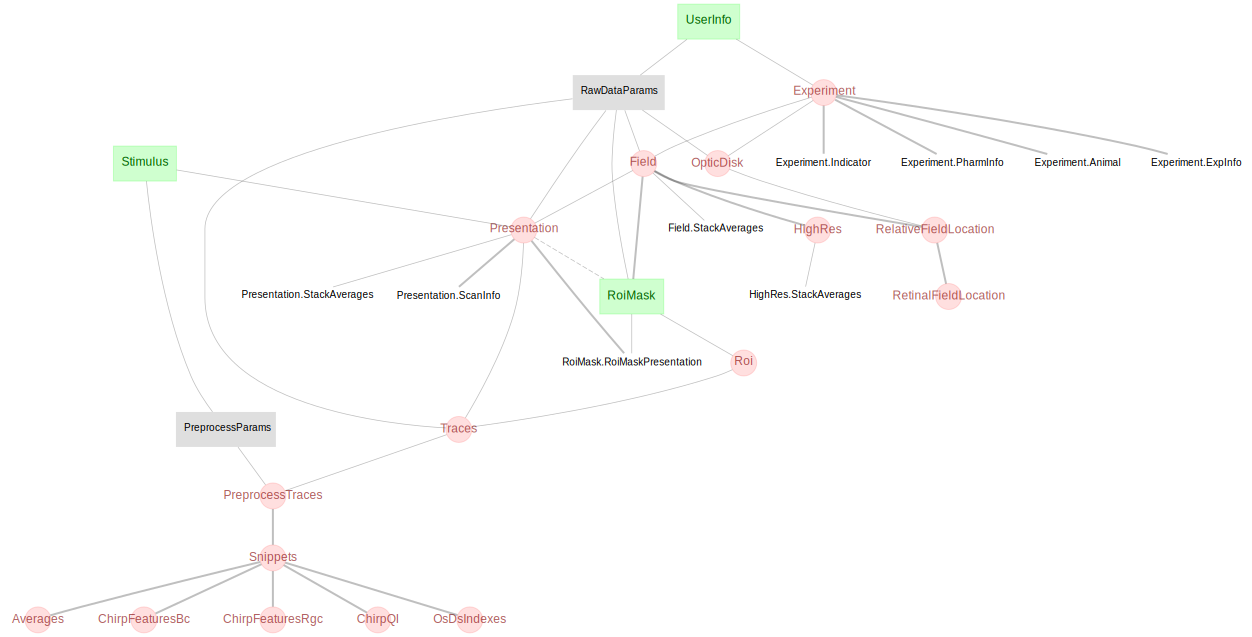

In [21]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)
    display(dj.ERD(schema))

## Upload user

In [15]:
userinfo = {
    'experimenter': 'TestUser', # Replace this if you want to use your own data
    'data_dir': '/gpfs01/euler/data/Data/DataJointTestData/xy-RGCs/', # Replace this if you want to use your own data
    'datatype_loc': 0,
    'animal_loc': 1,
    'region_loc': 2,
    'field_loc': 3,
    'stimulus_loc': 4,
    'cond1_loc': 5,
    'cond2_loc': 6,
    'cond3_loc': 7,
}

assert os.path.isdir(userinfo['data_dir'])

In [22]:
UserInfo().upload_user(userinfo)
UserInfo()

experimenter name of the experimenter,"data_dir path to header file, used for computed tables",field_loc string location for field,stimulus_loc string location for stimulus,animal_loc string location for number of animal (e.g. M1),datatype_loc string location for datatype (e.g. SMP),region_loc string location for region (e.g. LR or RR),cond1_loc string location for condition 1 (e.g. pharmacological),cond2_loc string location for condition 2 (e.g. pharmacological),cond3_loc string location for condition 3 (e.g. pharmacological),opticdisk_alias alias(es) for optic disk (separated by _),outline_alias alias(es) for retinal outline / edge (separated by _),highres_alias alias(es) for high resolution stack,mask_alias Ordered alias(es) for field roi mask (separated by _),pre_data_dir directory for h5 data files,raw_data_dir directory for smp and smh data files,"data_stack_name main data channel, e.g. OGB-1","alt_stack_name alternative data channel, e.g. SR101"
closedlooptest,/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/updated_loop_data/,3,4,1,None,2,5,None,None,od_opticdisk_opticdisc,outline_edge,hq_hr_highresolution_512,chirp_mb_movingbar,Pre,Raw,wDataCh0,wDataCh1
TestUser,/gpfs01/euler/data/Data/DataJointTestData/xy-RGCs/,3,4,1,0,2,5,6,7,od_opticdisk_opticdisc,outline_edge,hq_hr_highresolution_512,chirp_mb_movingbar,Pre,Raw,wDataCh0,wDataCh1


In [17]:
# Plot the data files in the selected folder
UserInfo().plot1(key=None, show_pre=False, show_raw=False, show_header=True)

/:  [0 files]
20250412/:  [0 files]


In [17]:
RawDataParams().add_default()
RawDataParams()

experimenter name of the experimenter,raw_id unique param set id,from_raw_data Load raw smp data (1) or h5 data (0),compute_from_stack Compute traces from stack. Otherwise try to import Igor traces.,include_artifacts automatically exclude all ROIs with artifacts?,trace_precision Compute traces with either line precision or pixel precision?,trigger_precision Compute triggers with either line precision or pixel precision?,"igor_roi_masks Either load or ignore existing ROI masks, e.g. from Igor"
TestUser,1,0,1,0,line,line,yes


## Populate data

### Experiments

In [18]:
Experiment().rescan_filesystem(verboselvl=2)
Experiment()

Scanning for experimenter: TestUser
	header_path: /gpfs01/euler/data/Data/DataJointTestData/xy-RGCs/20181011/2
		header_name: 20190704__right.ini
		Adding: {'experimenter': 'TestUser', 'date': datetime.datetime(2018, 10, 11, 0, 0), 'exp_num': 2}
	header_path: /gpfs01/euler/data/Data/DataJointTestData/xy-RGCs/20181011/1
		header_name: 20190701__left.ini
		Adding: {'experimenter': 'TestUser', 'date': datetime.datetime(2018, 10, 11, 0, 0), 'exp_num': 1}
	header_path: /gpfs01/euler/data/Data/DataJointTestData/xy-RGCs/20220125/2
		header_name: 20220126__right.ini
		Adding: {'experimenter': 'TestUser', 'date': datetime.datetime(2022, 1, 25, 0, 0), 'exp_num': 2}
	header_path: /gpfs01/euler/data/Data/DataJointTestData/xy-RGCs/20220215/1
		header_name: 20220217__left.ini
		Adding: {'experimenter': 'TestUser', 'date': datetime.datetime(2022, 2, 15, 0, 0), 'exp_num': 1}


experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,header_path path to header file,header_name name of header file
TestUser,2018-10-11,1,/gpfs01/euler/data/Data/DataJointTestData/xy-RGCs/20181011/1/,20190701__left.ini
TestUser,2018-10-11,2,/gpfs01/euler/data/Data/DataJointTestData/xy-RGCs/20181011/2/,20190704__right.ini
TestUser,2022-01-25,2,/gpfs01/euler/data/Data/DataJointTestData/xy-RGCs/20220125/2/,20220126__right.ini
TestUser,2022-02-15,1,/gpfs01/euler/data/Data/DataJointTestData/xy-RGCs/20220215/1/,20220217__left.ini


### Fields

In [19]:
Field().rescan_filesystem(verboselvl=2)

/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/core/field.py:128: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  file_info_df['cond1'].fillna('control', inplace=True)
/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/core/field.py:134: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values a

Found 9 files in 3 fields for key={'experimenter': 'TestUser', 'date': datetime.date(2018, 10, 11), 'exp_num': 1, 'raw_id': 1}
	Adding field: `{'field': 'GCL0', 'region': 'LR', 'cond1': 'control', 'experimenter': 'TestUser', 'date': datetime.date(2018, 10, 11), 'exp_num': 1, 'raw_id': 1}`
	Adding field: `{'field': 'GCL2', 'region': 'LR', 'cond1': 'control', 'experimenter': 'TestUser', 'date': datetime.date(2018, 10, 11), 'exp_num': 1, 'raw_id': 1}`
	Adding field: `{'field': 'GCL3', 'region': 'LR', 'cond1': 'control', 'experimenter': 'TestUser', 'date': datetime.date(2018, 10, 11), 'exp_num': 1, 'raw_id': 1}`


/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/core/field.py:128: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  file_info_df['cond1'].fillna('control', inplace=True)
/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/core/field.py:134: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values a

Found 16 files in 5 fields for key={'experimenter': 'TestUser', 'date': datetime.date(2018, 10, 11), 'exp_num': 2, 'raw_id': 1}
	Adding field: `{'field': 'GCL0', 'region': 'RR', 'cond1': 'control', 'experimenter': 'TestUser', 'date': datetime.date(2018, 10, 11), 'exp_num': 2, 'raw_id': 1}`
	Adding field: `{'field': 'GCL1', 'region': 'RR', 'cond1': 'control', 'experimenter': 'TestUser', 'date': datetime.date(2018, 10, 11), 'exp_num': 2, 'raw_id': 1}`
	Adding field: `{'field': 'GCL2', 'region': 'RR', 'cond1': 'control', 'experimenter': 'TestUser', 'date': datetime.date(2018, 10, 11), 'exp_num': 2, 'raw_id': 1}`
	Adding field: `{'field': 'GCL3', 'region': 'RR', 'cond1': 'control', 'experimenter': 'TestUser', 'date': datetime.date(2018, 10, 11), 'exp_num': 2, 'raw_id': 1}`
	Adding field: `{'field': 'GCL4', 'region': 'RR', 'cond1': 'control', 'experimenter': 'TestUser', 'date': datetime.date(2018, 10, 11), 'exp_num': 2, 'raw_id': 1}`


/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/core/field.py:128: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  file_info_df['cond1'].fillna('control', inplace=True)
/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/core/field.py:134: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values a

Found 24 files in 8 fields for key={'experimenter': 'TestUser', 'date': datetime.date(2022, 1, 25), 'exp_num': 2, 'raw_id': 1}
	Adding field: `{'field': 'GCL0', 'region': 'RR', 'cond1': 'C1', 'experimenter': 'TestUser', 'date': datetime.date(2022, 1, 25), 'exp_num': 2, 'raw_id': 1}`
	Adding field: `{'field': 'GCL0', 'region': 'RR', 'cond1': 'C2', 'experimenter': 'TestUser', 'date': datetime.date(2022, 1, 25), 'exp_num': 2, 'raw_id': 1}`
	Adding field: `{'field': 'GCL1', 'region': 'RR', 'cond1': 'C1', 'experimenter': 'TestUser', 'date': datetime.date(2022, 1, 25), 'exp_num': 2, 'raw_id': 1}`
	Adding field: `{'field': 'GCL1', 'region': 'RR', 'cond1': 'D', 'experimenter': 'TestUser', 'date': datetime.date(2022, 1, 25), 'exp_num': 2, 'raw_id': 1}`
	Adding field: `{'field': 'GCL2', 'region': 'RR', 'cond1': 'C1', 'experimenter': 'TestUser', 'date': datetime.date(2022, 1, 25), 'exp_num': 2, 'raw_id': 1}`
	Adding field: `{'field': 'GCL2', 'region': 'RR', 'cond1': 'D', 'experimenter': 'TestUser

/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/core/field.py:128: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  file_info_df['cond1'].fillna('control', inplace=True)
/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/core/field.py:134: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values a

Found 24 files in 8 fields for key={'experimenter': 'TestUser', 'date': datetime.date(2022, 2, 15), 'exp_num': 1, 'raw_id': 1}
	Adding field: `{'field': 'GCL0', 'region': 'LR', 'cond1': 'C1', 'experimenter': 'TestUser', 'date': datetime.date(2022, 2, 15), 'exp_num': 1, 'raw_id': 1}`
	Adding field: `{'field': 'GCL0', 'region': 'LR', 'cond1': 'C2', 'experimenter': 'TestUser', 'date': datetime.date(2022, 2, 15), 'exp_num': 1, 'raw_id': 1}`
	Adding field: `{'field': 'GCL1', 'region': 'LR', 'cond1': 'C1', 'experimenter': 'TestUser', 'date': datetime.date(2022, 2, 15), 'exp_num': 1, 'raw_id': 1}`
	Adding field: `{'field': 'GCL1', 'region': 'LR', 'cond1': 'D', 'experimenter': 'TestUser', 'date': datetime.date(2022, 2, 15), 'exp_num': 1, 'raw_id': 1}`
	Adding field: `{'field': 'GCL2', 'region': 'LR', 'cond1': 'C1', 'experimenter': 'TestUser', 'date': datetime.date(2022, 2, 15), 'exp_num': 1, 'raw_id': 1}`
	Adding field: `{'field': 'GCL2', 'region': 'LR', 'cond1': 'D', 'experimenter': 'TestUser

In [39]:
Field()

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),field_data_file info extracted from which file?,absx absolute position of the center (of the cropped field) in the x axis as recorded by ScanM,absy absolute position of the center (of the cropped field) in the y axis as recorded by ScanM,absz absolute position of the center (of the cropped field) in the z axis as recorded by ScanM,scan_type Type of scan,npixartifact Number of pixel with light artifact,nxpix number of pixels in x,nypix number of pixels in y,nzpix number of pixels in z,nxpix_offset number of offset pixels in x,nxpix_retrace number of retrace pixels in x,pixel_size_um width of a pixel in um (also height if y is second dimension),z_step_um z-step in um


In [ ]:
# If you call plot1 on a djimaging table, it will plot the given key.
# If you pass key=None or no key it will pick a key at random.
# This is implemented for most core tables and can be useful to get a quick impression of the data.
Field().plot1(key=None)

### Stimuli

#### Add default stimuli

In [20]:
# To compute receptive fields, the noise stimulus trace must be loaded and set!
import h5py

with h5py.File("/gpfs01/euler/data/Resources/Stimulus/noise.h5", "r") as f:
    noise_stimulus = f['stimulusarray'][:].T.astype(int)

In [21]:
Stimulus().add_nostim(skip_duplicates=True)
Stimulus().add_chirp(spatialextent=1000, stim_name='gChirp', alias="chirp_gchirp_globalchirp", skip_duplicates=True)
Stimulus().add_chirp(spatialextent=300, stim_name='lChirp', alias="lchirp_localchirp", skip_duplicates=True)
Stimulus().add_noise(stim_name='noise', pix_n_x=20, pix_n_y=15, pix_scale_x_um=30, pix_scale_y_um=30, stim_trace=noise_stimulus, skip_duplicates=True)
Stimulus().add_movingbar(skip_duplicates=True)

/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/core/stimulus.py:195: UserWarning: Stimulus offset not set. Assuming 0 offset. This is incorrect for the standard dense noise stimulus.
  warnings.warn(
/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/core/stimulus.py:203: UserWarning: Stimulus offset not set. Assuming 0 offset. This is incorrect for the standard dense noise stimulus.
  warnings.warn(
/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/core/stimulus.py:112: UserWarning: Values for ['bardx', 'bardy', 'velumsec', 'tmovedurs'] in `stim_dict` for stimulus `movingbar` are None. This may cause problems downstream.
  warnings.warn(f'Values for {missing_info} in `stim_dict` for stimulus `{stim_name}` are None. '
/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/core/stimulus.py:39: UserWarning: Number of triggers in trial_info=8 must match ntrigger_rep=1.
  warnings.warn(msg)


In [ ]:
# Add custom stimulus if needed
# Stimulus().add_stimulus(stim_name='my_stimulus', alias="stimname_stimnameabbr_alternativename", isrepeated=True, ntrigger_rep=6,
#                         trial_info=[1, 2, 3, 4, 5, 6], skip_duplicates=True)

In [ ]:
Stimulus().

[2025-04-21 20:08:16,146][INFO]: Deleting 2 rows from `ageuler_ssuhai_test`.`stimulus`


[2025-04-21 20:08:19,647][INFO]: Deletes committed.


2

#### Presentations

In [22]:
Presentation().populate(processes=20, display_progress=True)

Processes:   0%|          | 0/120 [00:00<?, ?it/s]/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/core/field.py:128: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  file_info_df['cond1'].fillna('control', inplace=True)
/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/core/field.py:128: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the in

{'success_count': 120, 'error_list': []}

In [42]:
Presentation()

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),pres_data_file path to file (e.g. h5 file),triggertimes triggertimes in each presentation,trigger_valid Are triggers as expected (1) or not (0)?,absx absolute position of the center (of the cropped field) in the x axis as recorded by ScanM,absy absolute position of the center (of the cropped field) in the y axis as recorded by ScanM,absz absolute position of the center (of the cropped field) in the z axis as recorded by ScanM,scan_type Type of scan,npixartifact number of pixel with light artifact,nxpix number of pixels in x,nypix number of pixels in y,nzpix number of pixels in z,nxpix_offset number of offset pixels in x,nxpix_retrace number of retrace pixels in x,pixel_size_um width of a pixel in um (also height if y is second dimension),z_step_um z-step in um,nframes number of pixels in time


In [ ]:
Presentation().plot1(key=None)

# AutoROIs

Skip/delete this if you don't want to use AutoROIs.

In [24]:
# If you have save some of you AutoROIs ROI masks you can load them here.
RoiMask().rescan_filesystem(verboselvl=2)
RoiMask()

Adding 1 ROI masks for field: {'experimenter': 'TestUser', 'date': datetime.date(2018, 10, 11), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL0', 'region': 'LR', 'cond1': 'control'}
Adding 1 ROI masks for field: {'experimenter': 'TestUser', 'date': datetime.date(2018, 10, 11), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL2', 'region': 'LR', 'cond1': 'control'}
Adding 1 ROI masks for field: {'experimenter': 'TestUser', 'date': datetime.date(2018, 10, 11), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL3', 'region': 'LR', 'cond1': 'control'}
Adding 1 ROI masks for field: {'experimenter': 'TestUser', 'date': datetime.date(2018, 10, 11), 'exp_num': 2, 'raw_id': 1, 'field': 'GCL0', 'region': 'RR', 'cond1': 'control'}
Adding 1 ROI masks for field: {'experimenter': 'TestUser', 'date': datetime.date(2018, 10, 11), 'exp_num': 2, 'raw_id': 1, 'field': 'GCL1', 'region': 'RR', 'cond1': 'control'}
Adding 1 ROI masks for field: {'experimenter': 'TestUser', 'date': datetime.date(2018, 10, 11), 'exp_num': 2, 'raw_id': 

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_mask ROI mask for recording field
TestUser,2018-10-11,1,1,GCL0,LR,control,gChirp,control,=BLOB=
TestUser,2018-10-11,1,1,GCL2,LR,control,gChirp,control,=BLOB=
TestUser,2018-10-11,1,1,GCL3,LR,control,gChirp,control,=BLOB=
TestUser,2018-10-11,2,1,GCL0,RR,control,gChirp,control,=BLOB=
TestUser,2018-10-11,2,1,GCL1,RR,control,gChirp,control,=BLOB=
TestUser,2018-10-11,2,1,GCL2,RR,control,gChirp,control,=BLOB=
TestUser,2018-10-11,2,1,GCL3,RR,control,gChirp,control,=BLOB=
TestUser,2018-10-11,2,1,GCL4,RR,control,gChirp,control,=BLOB=
TestUser,2022-01-25,2,1,GCL0,RR,C1,gChirp,control,=BLOB=
TestUser,2022-01-25,2,1,GCL0,RR,C2,gChirp,control,=BLOB=


In [25]:
# Find all the fields that still require a ROI mask.
missing_fields = RoiMask().list_missing_field()

In [26]:
field_key = missing_fields.pop()  # Pick one field

# Load ROI canvas, draw the ROI mask, clean it if you want, shift if you want.
# You can then save it to a file to be able to load it again later.
roi_canvas = RoiMask().draw_roi_mask(field_key=field_key, canvas_width=30)
roi_canvas.start_gui()

IndexError: pop from empty list

In [27]:
# Load the just saved ROI mask
RoiMask().rescan_filesystem(verboselvl=2)

[]

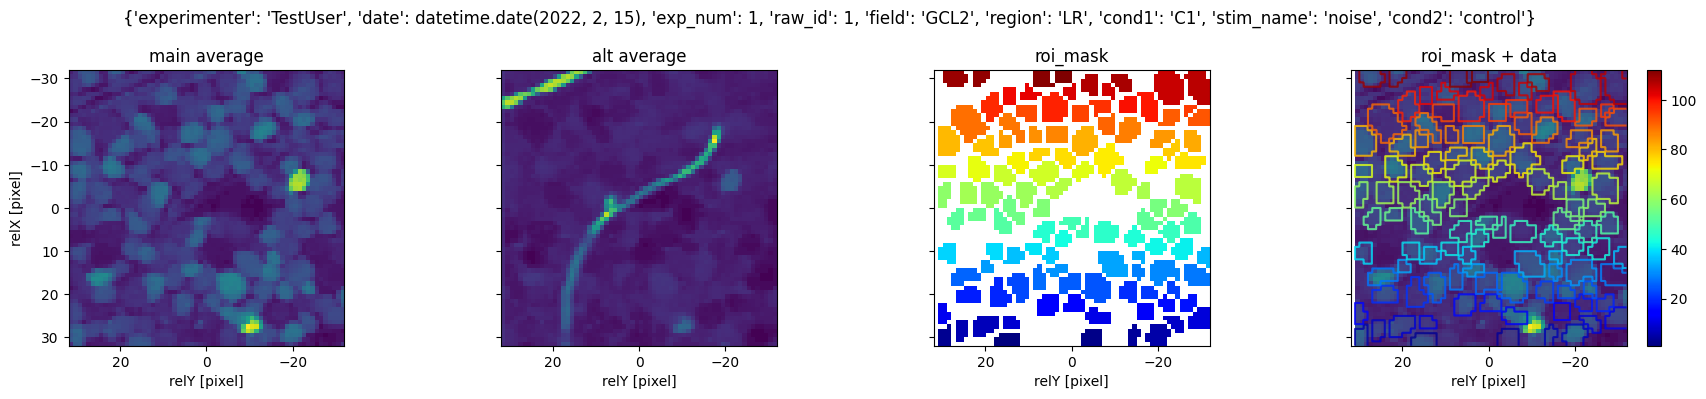

In [28]:
RoiMask().plot1()

# Rois

In [ ]:
Roi().populate(processes=20, display_progress=True)
Roi()

In [ ]:
Roi().plot1(key=None)

### Traces

In [ ]:
Traces().populate(processes=20, display_progress=True)
Traces()

In [ ]:
PreprocessParams().add_default(skip_duplicates=True)
PreprocessParams()

In [ ]:
PreprocessTraces().populate(processes=20, display_progress=True)
PreprocessTraces()

In [ ]:
PreprocessTraces().plot1(key=None)

In [ ]:
Snippets().populate(processes=20, display_progress=True)
Snippets()

In [ ]:
Snippets().plot1(key=None)

In [ ]:
Averages().populate(processes=20, display_progress=True)
Averages()

In [ ]:
Averages().plot({"stim_name": "gChirp"})

## Quality and statistics

In [ ]:
ChirpQI().populate(display_progress=True, processes=20)
ChirpQI()

In [ ]:
OsDsIndexes().populate(display_progress=True, processes=20)
OsDsIndexes()

## Recording location

In [ ]:
OpticDisk().populate(processes=20, display_progress=True)
OpticDisk()

In [ ]:
RelativeFieldLocation().populate(processes=20, display_progress=True)
RelativeFieldLocation()

In [ ]:
RelativeFieldLocation().plot()

In [ ]:
RetinalFieldLocation().populate(processes=20, display_progress=True)
RetinalFieldLocation()

In [ ]:
RetinalFieldLocation().plot()

# RGC Classifier

Skip/delete this is you don't want to use the RGC classifier

In [ ]:
try:
    CelltypeAssignment()
except Exception as e:
    import warnings
    warnings.warn("""
        If you want to include the RGC classifier in your database, you have to copy the respective tables from 
        djimaging/schemas/rgc_classifier_schema.py 
        to the schema you just imported (see above).
        Then restart the notebook and try again.
        """)

### Add classifier method

In [ ]:
ClassifierMethod().add_default(skip_duplicates=True)
ClassifierMethod()

## Add training data

In [ ]:
ClassifierTrainingData().add_default(skip_duplicates=True)
ClassifierTrainingData()

## Train classifier

In [ ]:
Classifier().populate()
Classifier()

## Assign RGC types

In [ ]:
Baden16Traces().populate(display_progress=True, processes=20)

In [ ]:
CelltypeAssignment().populate(display_progress=True)
CelltypeAssignment()

In [ ]:
CelltypeAssignment().plot(threshold_confidence=0.0)
CelltypeAssignment().plot(threshold_confidence=0.25)
CelltypeAssignment().plot(threshold_confidence=0.5)

# Clean up

If you are done with the tutorial you can delete (=drop) your schema again and create a schema with a more meaningful name than `ageuler_{username}_test`.

In [18]:
if input("Continue with cleaning up? (yes/no))") != "yes":
    raise ValueError('Enter yes if you wish to continue.')

schema.drop()